# Backpropagation in Multilayer Neural Networks

While we will primarily be working with high-level, abstract toolkits like Keras in this course, understanding how backpropagation works is absolutely essential to using neural networks. 

In this exercise, we will build our own backpropagation algorithm - working through each step, to ensure that we can follow it.

Just like in Lab 1, we'll be working with the MNIST dataset. We will load it and plot an example:

In [1]:
# The CODE in THIS FILE has been adjusted to be run with kernel GTX1060_cp, which contains CuPY prepared for CUDA toolkit 11.2

In [2]:
import time
start = time.perf_counter()

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import cupy as cp
import numpy as np
from sklearn.datasets import load_digits

digits = load_digits()

In [4]:
import os
import random

# Set seeds for all randomness sources
os.environ["PYTHONHASHSEED"] = "0"
random.seed(42)
cp.random.seed(42)

# Use a single RNG instance
rng = cp.random.default_rng(31416)

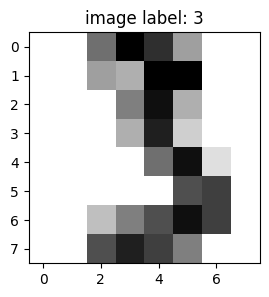

In [5]:
sample_index = 45
plt.figure(figsize=(3, 3))
plt.imshow(digits.images[sample_index], cmap=plt.cm.gray_r,
           interpolation='nearest')
plt.title("image label: %d" % digits.target[sample_index]);

### Preprocessing

Of course, we need to split our data into training and testing sets before we use it, just the same as in Lab 1:

In [6]:
from sklearn.model_selection import train_test_split

data = cp.asarray(digits.data, dtype='float32')
target = cp.asarray(digits.target, dtype='int32')

X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.15, random_state=37)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape )

(1527, 64) (1527,) (270, 64) (270,)


# Numpy Implementation

## a) Logistic Regression

In this section we will implement a logistic regression model trainable with SGD using numpy. Here are the objectives:

- Implement the softmax function $\sigma(\mathbf{x})_i = \frac{e^{x_i}}{\sum_{j=1}^n e^{x_j}}$;
- Implement the negative log likelihood function $NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}$;
- Train a logistic regression model on the MNIST dataset;
- Evaluate the model on the training and testing sets.

Before we get there, let's write a function that one-hot encodes the class labels:

In [7]:
# def one_hot(n_classes, y):
#     return cp.eye(n_classes)[y]

import cupy as cp

def one_hot(num_classes, index):
    import cupy as cp

    # Convert to Python list of ints
    if isinstance(index, cp.ndarray):
        if index.ndim == 0:
            index = [int(cp.asnumpy(index))]
        else:
            index = [int(i) for i in cp.asnumpy(index)]
    elif isinstance(index, (list, tuple, cp.ndarray)):
        index = [int(i) for i in index]
    else:
        index = [int(index)]

    one_hot_array = cp.zeros(num_classes)
    for i in index:
        one_hot_array[i] = 1
    return one_hot_array

In [8]:
one_hot(num_classes=10, index=3)

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [9]:
one_hot(num_classes=10, index=[0, 4, 9, 1])

array([1., 1., 0., 0., 1., 0., 0., 0., 0., 1.])

### The softmax function

Now we will implement the softmax function. Recall that the softmax function is defined as follows:

$$
softmax(\mathbf{x}) = \frac{1}{\sum_{i=1}^{n}{e^{x_i}}}
\cdot
\begin{bmatrix}
  e^{x_1}\\\\
  e^{x_2}\\\\
  \vdots\\\\
  e^{x_n}
\end{bmatrix}
$$

This is implemented for you using numpy - we want to be able to apply the softmax function to a batch of samples at once, so we will use numpy's vectorized operations to do so.

Our method also handles _stability issues_ that can occur when the values in `X` are very large. We will subtract the maximum value from each row of `X` to avoid overflow in the exponentiation. This isn't part of the softmax function itself, but it's a useful trick to know about.

In [10]:
def softmax(X):
    X_max = cp.max(X, axis=-1, keepdims=True)
    exp = cp.exp(X - X_max) # Subtract the max to avoid overflow in the exponentiation
    return exp / cp.sum(exp, axis=-1, keepdims=True)


Let's make sure that this works one vector at a time (and check that the components sum to one):

In [11]:
print(softmax(cp.array((10, 2, -3)))) # cp.array((10, 2, -3), args)

[9.99662391e-01 3.35349373e-04 2.25956630e-06]


When we are using our model to make predictions, we will want to be able to make predictions for multiple samples at once.
Let's make sure that our implementation of softmax works for a batch of samples:

In [12]:
X = cp.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


Probabilities should sum to 1:

In [13]:
print(cp.sum(softmax(cp.array((10, 2, -3)))))

1.0


In [14]:
print("softmax of 2 vectors:")
X = cp.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

softmax of 2 vectors:
[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


The sum of probabilities for each input vector of logits should some to 1:

In [15]:
print(cp.sum(softmax(X), axis=1))

[1. 1.]


Now we will implement a function that, given the true one-hot encoded class `Y_true` and some predicted probabilities `Y_pred`, returns the negative log likelihood.

Recall that the negative log likelihood is defined as follows:

$$
NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}
$$

For example, if we have $y_{true} = [1, 0, 0]$ and $y_{pred} = [0.99, 0.01, 0]$, then the negative log likelihood is $- \log(0.99) \approx 0.01$.

In [16]:
def nll(Y_true, Y_pred):
    Y_true = cp.asarray(Y_true)
    Y_pred = cp.asarray(Y_pred)

    # Ensure Y_pred doesn't have zero probabilities to avoid log(0)
    Y_pred = cp.clip(Y_pred, 1e-15, 1 - 1e-15)

    # Calculate negative log likelihood
    loss = -cp.sum(Y_true * cp.log(Y_pred))
    return loss

# Make sure that it works for a simple sample at a time
print(nll([1, 0, 0], [.99, 0.01, 0]))

0.01005033585350145


We should see a very high value for this negative log likelihood, since the model is very confident that the third class is the correct one, but the true class is the first one:

In [17]:
print(nll([1, 0, 0], [0.01, 0.01, .98]))

4.605170185988091


Make sure that your implementation can compute the average negative log likelihood of a group of predictions: `Y_pred` and `Y_true` can therefore be past as 2D arrays:

In [18]:
# Check that the average NLL of the following 3 almost perfect
# predictions is close to 0
Y_true = cp.array([[0, 1, 0],
                   [1, 0, 0],
                   [0, 0, 1]])

Y_pred = cp.array([[0,   1,    0],
                   [.99, 0.01, 0],
                   [0,   0,    1]])

print(nll(Y_true, Y_pred))

0.010050335853503449


Now that we have our softmax and negative log likelihood functions, we can implement a logistic regression model. 
In this section, we have built the model for you, but you will need to complete a few key parts.

**YOUR TURN:**

1. Implement the `forward` method of the `LogisticRegression` class. This method should take in a batch of samples `X` and return the predicted probabilities for each class. You should use the softmax function that we implemented earlier.
2. Implement the `loss` method of the `LogisticRegression` class. This method take in the samples `X` and the true values `y` and return the average negative log likelihood of the predictions.

In [19]:
# This would be 1 layer of 10 neurons

class LogisticRegression:

    def __init__(self, input_size, output_size):
        # Initialize the weights and biases with random numbers
        self.W = rng.uniform(size=(input_size, output_size),
                                   high=0.1, low=-0.1)
        self.b = rng.uniform(size=output_size,
                                   high=0.1, low=-0.1)
        
        # Store the input size and output size
        self.output_size = output_size
        self.input_size = input_size
        
    def forward(self, X):
        # Compute the linear combination of the input and weights
        Z = cp.dot(X, self.W) + self.b
        return softmax(Z)
    
    def predict(self, X):
        # Return the most probable class for each sample in X
        if len(X.shape) == 1:
            return cp.argmax(self.forward(X))
        else:
            return cp.argmax(self.forward(X), axis=1)
            
    def loss(self, X, y):
        # Compute the negative log likelihood over the data provided
        y_onehot = one_hot(self.output_size, y.astype(int))
        y_pred = self.forward(X)
        return nll(y_onehot, y_pred)

    def grad_loss(self, X, y_true, y_pred):
        # Compute the gradient of the loss with respect to W and b for a single sample (X, y_true)
        # y_pred is the output of the forward pass
    
        # Gradient with respect to weights
        grad_W = cp.dot(X.T, (y_pred - y_true))
    
        # Gradient with respect to biases
        grad_b = cp.sum(y_pred - y_true, axis=0)
    
        return grad_W, grad_b
    
# Raise an exception if you try to run this cell without having implemented the LogisticRegression class
model = LogisticRegression(input_size=64, output_size=10)
try:
    assert(model.forward(cp.zeros((1, 64))).shape == (1, 10))
    assert(model.loss(cp.zeros((1, 64)), cp.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the LogisticRegression class.")

In [20]:
# Build a model and test its forward inference
n_features = X_train.shape[1]
n_classes = len(cp.unique(y_train))
lr = LogisticRegression(n_features, n_classes)

We can evaluate the model on an example, visualizing the prediction probabilities:

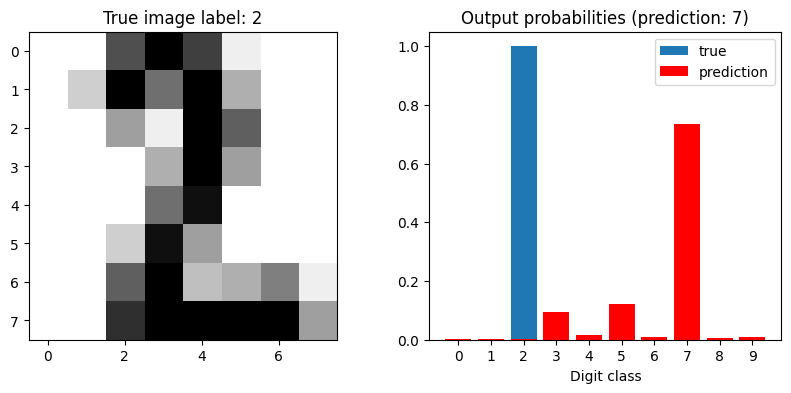

In [21]:
def plot_prediction(model, sample_idx=0, classes=range(10)):
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

    ax0.imshow(X_test[sample_idx:sample_idx+1].get().reshape(8, 8),
                cmap=plt.cm.gray_r, interpolation='nearest')
    # ax0.imshow(X_test[sample_idx:sample_idx+1].reshape(8, 8),
    #            cmap=plt.cm.gray_r, interpolation='nearest')
    ax0.set_title("True image label: %d" % y_test[sample_idx])

    ax1.bar(classes, one_hot(len(classes), y_test[sample_idx]).get(), label='true')
    ax1.bar(classes, model.forward(X_test[sample_idx]).get(), label='prediction', color="red")
    ax1.set_xticks(classes)
    prediction = model.predict(X_test[sample_idx])
    ax1.set_title('Output probabilities (prediction: %d)'
                  % prediction)
    ax1.set_xlabel('Digit class')
    ax1.legend()

plot_prediction(lr, sample_idx=0)
    

Now it's time to start training! We will train for a single epoch, and then evaluate the model on the training and testing sets. Read through the following and make sure that you understand what we are doing here.

In [22]:
lr = LogisticRegression(input_size=X_train.shape[1], output_size=10)

learning_rate = 0.01

for i in range(len(X_train)):
    # Get the current sample and corresponding label
    x = X_train[i:i+1]  # Reshape to keep the batch dimension
    y = y_train[i:i+1]  # Reshape to keep the batch dimension

    # Compute the forward pass and the gradient of the loss with respect to W and b
    y_pred = lr.forward(x)
    grad_W, grad_b = lr.grad_loss(x, one_hot(lr.output_size, y), y_pred)

    # Update the weights and biases
    lr.W -= learning_rate * grad_W
    lr.b -= learning_rate * grad_b

    # Print the average negative log likelihood every 100 steps
    if i % 100 == 0:
        avg_nll = lr.loss(X_train[max(0, i-100):i], y_train[max(0, i-100):i])
        print("Average NLL over the last 100 samples at step %d: %0.f" % (i, avg_nll))


Average NLL over the last 100 samples at step 0: -0
Average NLL over the last 100 samples at step 100: 26521
Average NLL over the last 100 samples at step 200: 26879
Average NLL over the last 100 samples at step 300: 27768
Average NLL over the last 100 samples at step 400: 28069
Average NLL over the last 100 samples at step 500: 28153
Average NLL over the last 100 samples at step 600: 29087
Average NLL over the last 100 samples at step 700: 29057
Average NLL over the last 100 samples at step 800: 29931
Average NLL over the last 100 samples at step 900: 29604
Average NLL over the last 100 samples at step 1000: 28904
Average NLL over the last 100 samples at step 1100: 29450
Average NLL over the last 100 samples at step 1200: 29085
Average NLL over the last 100 samples at step 1300: 29279
Average NLL over the last 100 samples at step 1400: 30087
Average NLL over the last 100 samples at step 1500: 30222


Evaluate the trained model on the first example:

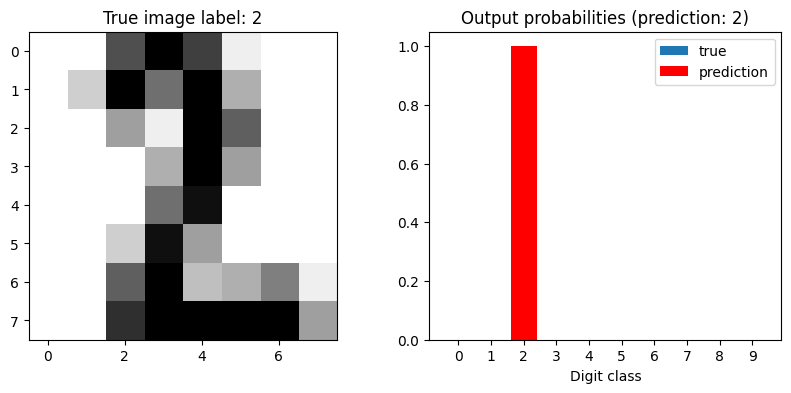

In [23]:
plot_prediction(lr, sample_idx=0)

## b) Feedforward Multilayer

The objective of this section is to implement the backpropagation algorithm (SGD with the chain rule) on a single layer neural network using the sigmoid activation function.

Now it's your turn to

- Implement the `sigmoid` and its element-wise derivative `dsigmoid` functions:

$$
sigmoid(x) = \frac{1}{1 + e^{-x}}
$$

$$
dsigmoid(x) = sigmoid(x) \cdot (1 - sigmoid(x))
$$

Remember that you can use your `sigmoid` function inside your `dsigmoid` function.

Just like with our softmax function, we also want to make sure that we don't run into stability issues with our sigmoid function. We will use `cp.clip` to ensure that the input to the sigmoid function is not too large or too small.

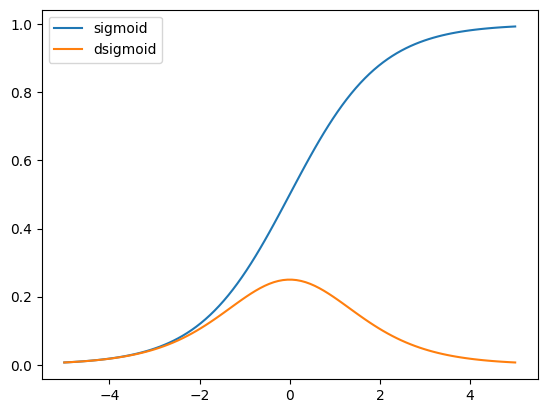

In [24]:
def sigmoid(X):
    # Clip X to prevent overflow or underflow
    X = cp.clip(X, -500, 500) # This ensures that cp.exp(X) doesn't overflow
    return 1 / (1 + cp.exp(-X))


def dsigmoid(X):
    return sigmoid(X) * (1 - sigmoid(X))


x = cp.linspace(-5, 5, 100)
plt.plot(x.get(), sigmoid(x).get(), label='sigmoid')
plt.plot(x.get(), dsigmoid(x).get(), label='dsigmoid')
plt.legend(loc='best');

Now it's your turn to complete the neural network code, so that we can train it on the MNIST dataset.

Some parts have been completed for you already. Often, you'll be able to refer back to the code from the previous section to help you complete the code in this section.

In [25]:
# This would be 1 layer of 32 neurons and 1 layer of 10 neurons. 

class NeuralNet():
    """MLP with 1 hidden layer with a sigmoid activation"""

    def __init__(self, input_size, hidden_size, output_size):
        # Initializes the weights with random numbers
        self.W_h = rng.uniform(size=(input_size, hidden_size),
                                     high=0.1, low=-0.1)
        self.b_h = rng.uniform(size=hidden_size,
                                     high=0.1, low=-0.1)
        self.W_o = rng.uniform(size=(hidden_size, output_size),
                                     high=0.1, low=-0.1)
        self.b_o = rng.uniform(size=output_size,
                                     high=0.1, low=-0.1)

        # Store the input size, hidden size and output size
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

    def forward_hidden(self, X):
        # Compute the linear combination of the input and weights
        self.Z_h = cp.dot(X, self.W_h) + self.b_h

        # Apply the sigmoid activation function
        return sigmoid(self.Z_h)

    def forward_output(self, H):
        # Compute the linear combination of the hidden layer activation and weights
        self.Z_o = cp.dot(H, self.W_o) + self.b_o

        # Apply the sigmoid activation function
        return sigmoid(self.Z_o)

    def forward(self, X):
        # Compute the forward activations of the hidden and output layers
        H = self.forward_hidden(X)
        Y = self.forward_output(H)

        return Y

    def loss(self, X, y):
        y = y.astype(int)
        y_onehot = one_hot(self.output_size, y.astype(int))
        y_pred = self.forward(X)
        return nll(y_onehot, y_pred)

    def grad_loss(self, X, y_true):
        y_true = one_hot(self.output_size, y_true)
        y_pred = self.forward(X)

        # Compute the error at the output layer
        error_o = y_pred - y_true

        # Compute the gradient of the loss with respect to W_o and b_o
        grad_W_o = cp.dot(self.Z_h.T, error_o)
        grad_b_o = cp.sum(error_o, axis=0)

        # Compute the error at the hidden layer
        error_h = cp.dot(error_o, self.W_o.T) * dsigmoid(self.Z_h)

        # Compute the gradient of the loss with respect to W_h and b_h
        grad_W_h = cp.dot(X.T, error_h)
        grad_b_h = cp.sum(error_h, axis=0)

        return {"W_h": grad_W_h, "b_h": grad_b_h, "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, x, y, learning_rate):
        # Ensure x is 2D
        x = x[cp.newaxis, :]
        # Compute the gradient for the sample and update the weights
        grads = self.grad_loss(x, y)
    
        self.W_h -= learning_rate * grads["W_h"]
        self.b_h -= learning_rate * grads["b_h"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]
        
    def predict(self, X):
        if len(X.shape) == 1:
            return cp.argmax(self.forward(X))
        else:
            return cp.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        y_preds = cp.argmax(self.forward(X), axis=1)
        return cp.mean(y_preds == y)
    
# Raise an exception if you try to run this cell without having implemented the NeuralNet class
nn = NeuralNet(input_size=64, hidden_size=32, output_size=10)
try:
    assert(nn.forward(cp.zeros((1, 64))).shape == (1, 10))
    assert(nn.loss(cp.zeros((1, 64)), cp.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the NeuralNet class.")

Once the code is written, we can test our model on a single sample:

In [26]:
n_hidden = 10
model = NeuralNet(n_features, n_hidden, n_classes)

In [27]:
model.loss(X_train, y_train)

array(10546.44368483)

In [28]:
model.accuracy(X_train, y_train)

array(0.12573674)

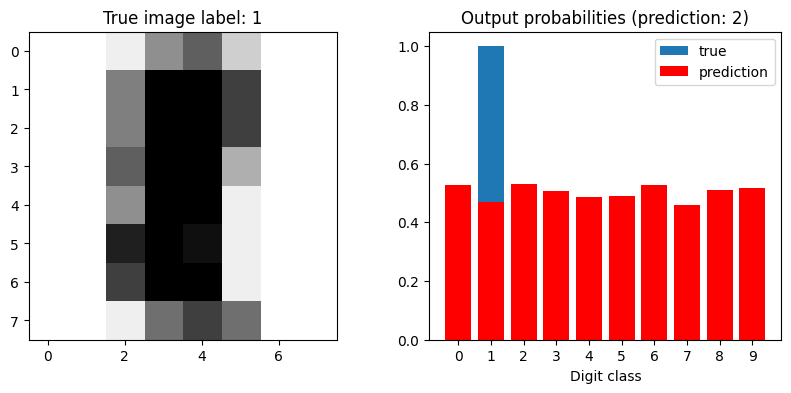

In [29]:
plot_prediction(model, sample_idx=5)

And now it's time to train!

In [30]:
losses, accuracies, accuracies_test = [], [], []
losses.append(model.loss(X_train, y_train))
accuracies.append(model.accuracy(X_train, y_train))
accuracies_test.append(model.accuracy(X_test, y_test))

print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
      % (losses[-1], accuracies[-1], accuracies_test[-1]))

for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.001) # Note: here 0.001 is the learning rate

    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))

Random init: train loss: 10546.44368, train acc: 0.126, test acc: 0.163
Epoch #1, train loss: 34467.40980, train acc: 0.220, test acc: 0.185
Epoch #2, train loss: 33945.05751, train acc: 0.463, test acc: 0.433
Epoch #3, train loss: 35882.46583, train acc: 0.698, test acc: 0.622
Epoch #4, train loss: 39202.34795, train acc: 0.815, test acc: 0.756
Epoch #5, train loss: 43225.29246, train acc: 0.859, test acc: 0.815
Epoch #6, train loss: 47615.64515, train acc: 0.889, test acc: 0.859
Epoch #7, train loss: 51557.15477, train acc: 0.912, test acc: 0.870
Epoch #8, train loss: 55092.94619, train acc: 0.928, test acc: 0.874
Epoch #9, train loss: 58285.62594, train acc: 0.935, test acc: 0.889
Epoch #10, train loss: 61165.99232, train acc: 0.938, test acc: 0.896
Epoch #11, train loss: 63666.04338, train acc: 0.944, test acc: 0.900
Epoch #12, train loss: 65752.63356, train acc: 0.950, test acc: 0.904
Epoch #13, train loss: 67661.09516, train acc: 0.954, test acc: 0.907
Epoch #14, train loss: 6945

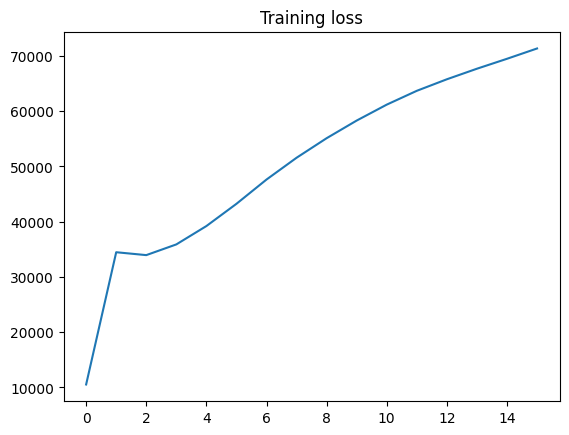

In [31]:
plt.plot(cp.array(losses).get())
plt.title("Training loss");

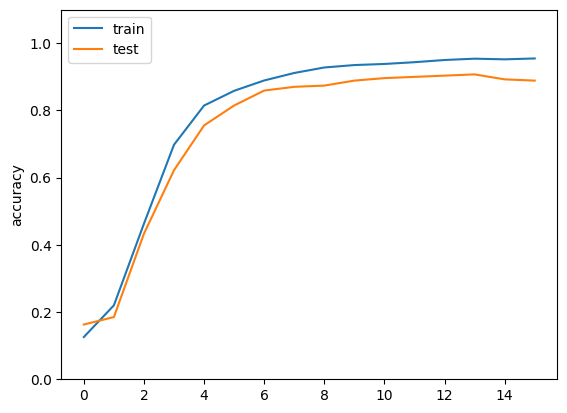

In [32]:
plt.plot(cp.array(accuracies).get(), label='train')
plt.plot(cp.array(accuracies_test).get(), label='test')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.legend(loc='best');

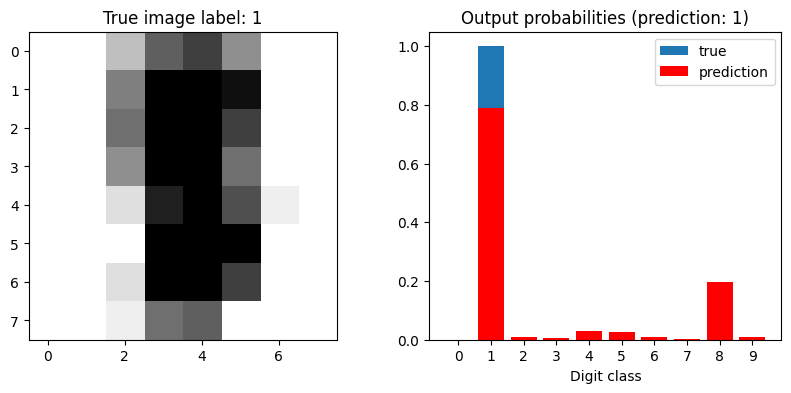

In [33]:
plot_prediction(model, sample_idx=4)

## c) Exercises

### Look at worst prediction errors

- Use numpy to find test samples for which the model made the worst predictions,
- Use the `plot_prediction` to look at the model predictions on those,
- Would you have done any better?

In [34]:
# Compute loss values of the test set, and find the 9 highest losses
# Step 1: Accumulate loss values in a list
test_losses = []
for x, y in zip(X_test, y_test):
    test_losses.append(model.loss(x, y))

# Step 2: Convert to CuPy array for GPU-friendly sorting
test_losses_cp = cp.array(test_losses)
ind_worse = cp.argpartition(test_losses_cp, -9)[-9:]

# Step 3: Convert losses to NumPy for indexing and sorting
test_losses_np = cp.asnumpy(test_losses_cp)
ind_worse_np = cp.asnumpy(ind_worse)

# Step 4: Extract and sort worst predictions
worst_pred = test_losses_np[ind_worse_np]
worst_pred = cp.sort(worst_pred)[::-1]
worst_pred

array([6.03608683, 3.50955114, 3.42036634, 2.97146886, 2.79580655,
       2.76759153, 2.63217231, 2.55686968, 2.44526374])

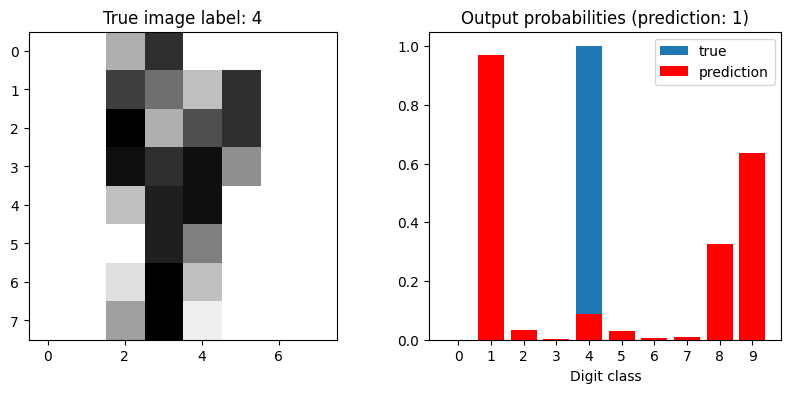

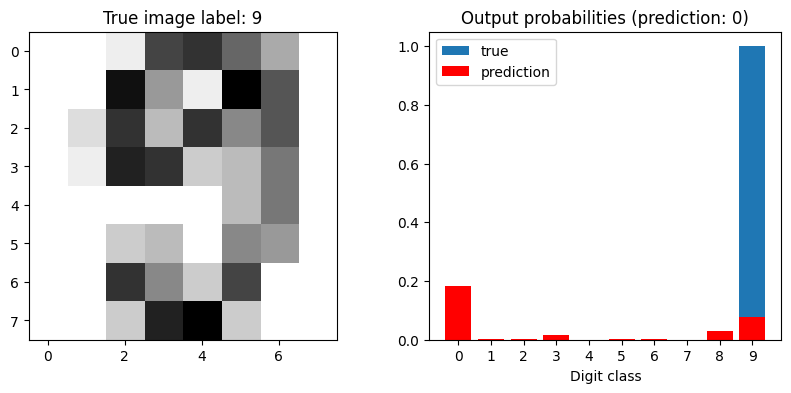

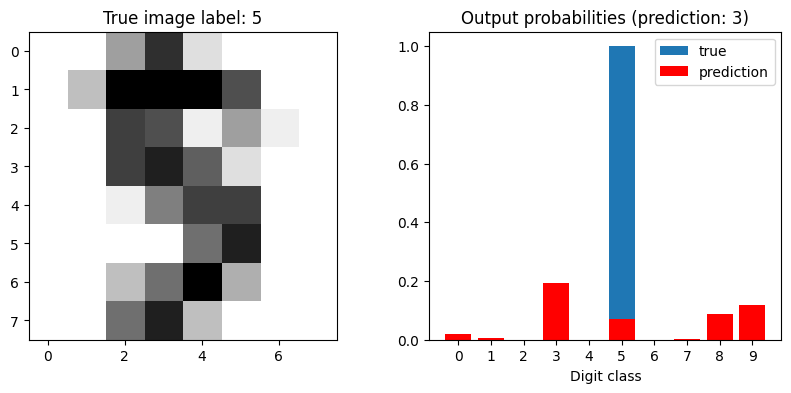

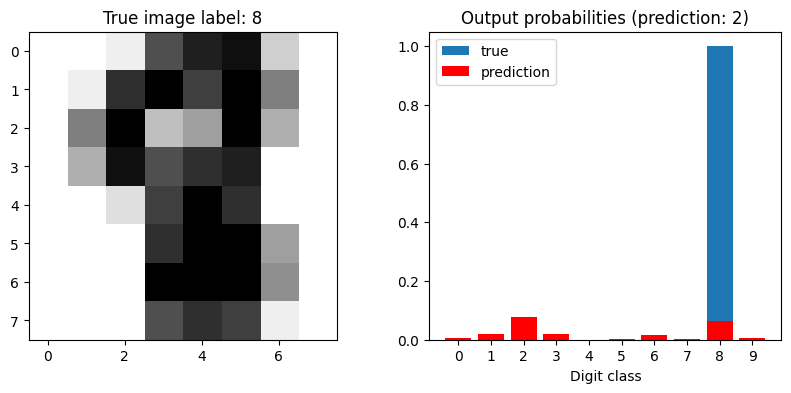

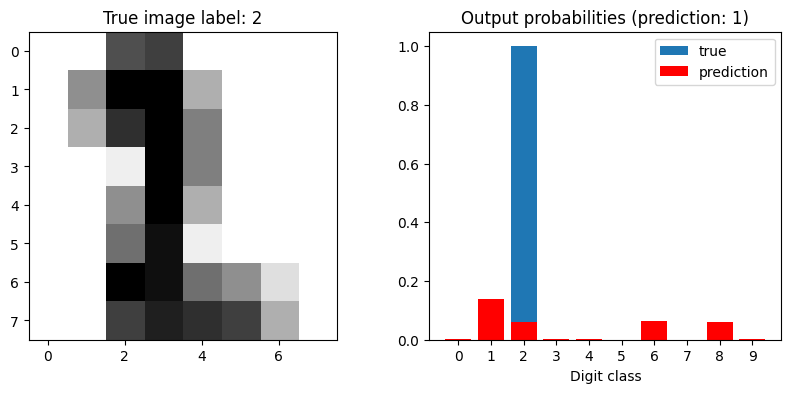

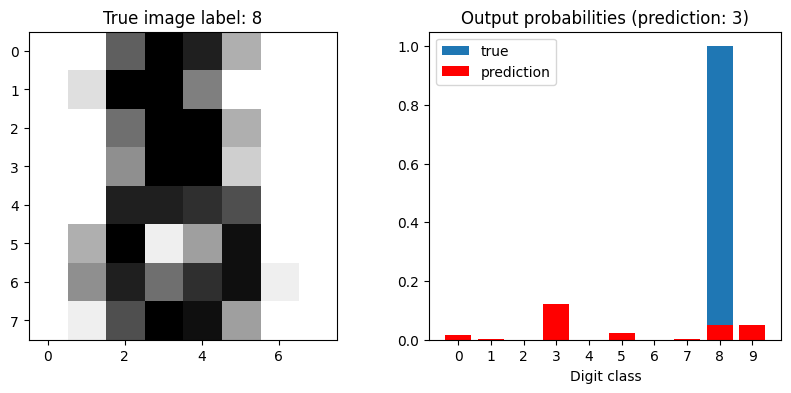

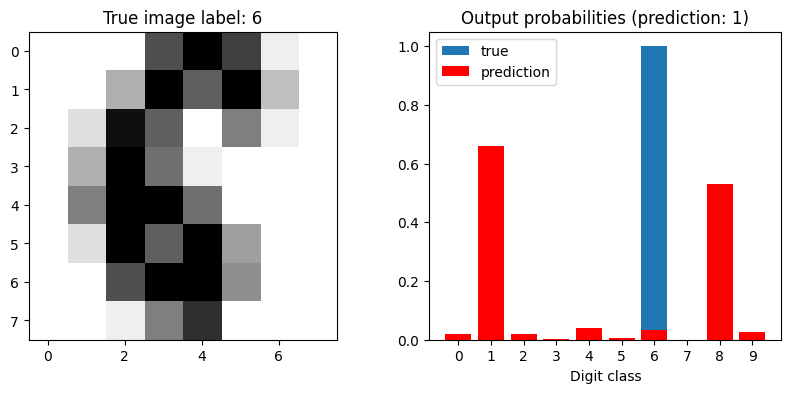

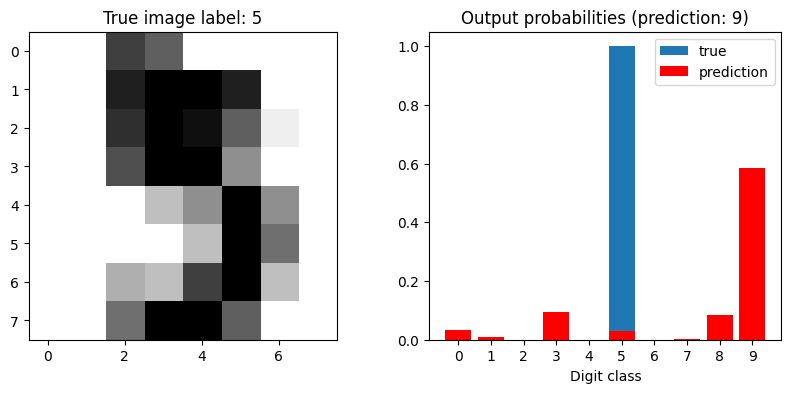

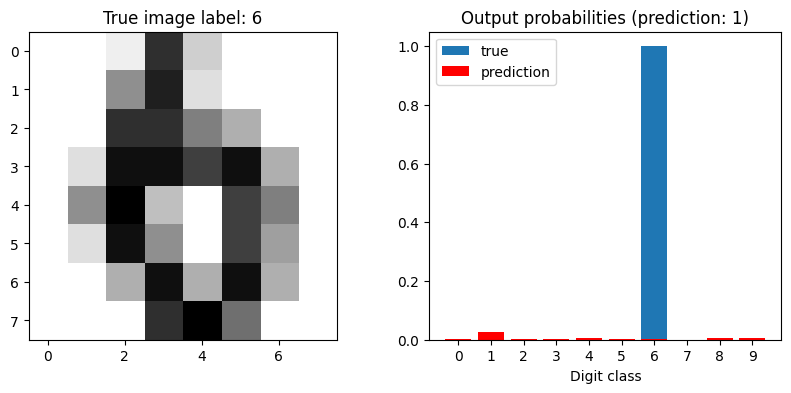

In [35]:
# Let's look at the model predictions on those image with high losses
for i in range(9):
    plot_prediction(model, sample_idx=ind_worse[i])


I would have not done much better because some of these images are not clear neither for a human 

### Hyper parameters settings

- Experiment with different hyperparameters:
  - learning rate,
  - size of hidden layer,
  - implement the support for a second hidden layer.
  - What is the best test accuracy you can get?

In [36]:
# Let's train with a different learning rate
n_hidden = 10
rng = cp.random.default_rng(31416)  # Reset the RNG
model = NeuralNet(n_features, n_hidden, n_classes)
model.loss(X_train, y_train)
model.accuracy(X_train, y_train)
losses, accuracies, accuracies_test = [], [], []
losses.append(model.loss(X_train, y_train))
accuracies.append(model.accuracy(X_train, y_train))
accuracies_test.append(model.accuracy(X_test, y_test))

print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
      % (losses[-1], accuracies[-1], accuracies_test[-1]))

for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.002) # Note: here 0.002 is the learning rate
    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))

Random init: train loss: 10879.72268, train acc: 0.145, test acc: 0.115
Epoch #1, train loss: 34751.26850, train acc: 0.554, test acc: 0.537
Epoch #2, train loss: 40132.98635, train acc: 0.783, test acc: 0.785
Epoch #3, train loss: 47635.72583, train acc: 0.896, test acc: 0.852
Epoch #4, train loss: 55572.29706, train acc: 0.925, test acc: 0.885
Epoch #5, train loss: 62449.96991, train acc: 0.936, test acc: 0.896
Epoch #6, train loss: 67263.81493, train acc: 0.944, test acc: 0.881
Epoch #7, train loss: 72030.71406, train acc: 0.946, test acc: 0.889
Epoch #8, train loss: 76356.37848, train acc: 0.953, test acc: 0.896
Epoch #9, train loss: 80018.40732, train acc: 0.960, test acc: 0.907
Epoch #10, train loss: 83760.83516, train acc: 0.957, test acc: 0.904
Epoch #11, train loss: 86359.58175, train acc: 0.962, test acc: 0.904
Epoch #12, train loss: 89295.62292, train acc: 0.961, test acc: 0.904
Epoch #13, train loss: 92576.94086, train acc: 0.963, test acc: 0.915
Epoch #14, train loss: 9480

- Experiment with different hyperparameters:
  - learning rate,

Learning rate: 0.01 and 0.1; loss does not converge and keeps growing

Learning rate: 0.0001, looks like converging, but will need many more epochs.

Learning rate: 0.001, baseline:                                                     Epoch #15, train loss: 412.77427, train acc: 0.949, test acc: 0.919

Learning rate: 0.002, converges faster, bounces and goes back to the good result:   Epoch #15, train loss: 338.42941, train acc: 0.953, test acc: 0.944

Learning rate: 0.0005, converges faster, bounces and goes back to the good result:  Epoch #15, train loss: 877.32609, train acc: 0.933, test acc: 0.930

Learning rate of 0.002 is good

- Experiment with different hyperparameters:
  - size of hidden layer

n_hidden = 10 baseline:   Epoch #15, train loss: 338.42941, train acc: 0.953, test acc: 0.944

n_hidden = 20             Epoch #15, train loss: 170.30764, train acc: 0.978, test acc: 0.948

n_hidden = 30             Epoch #15, train loss: 139.43346, train acc: 0.983, test acc: 0.948

n_hidden = 40             Epoch #15, train loss: 133.56811, train acc: 0.991, test acc: 0.967

n_hidden = 100            Epoch #15, train loss: 96.40518, train acc: 0.996, test acc: 0.978

n_hidden = 200            Epoch #15, train loss: 77.40919, train acc: 0.996, test acc: 0.978

n_hidden = 1000           Epoch #15, train loss: 57.16290, train acc: 0.994, test acc: 0.963

n_hidden = 10000          Epoch #15, train loss: 81.19605, train acc: 0.967, test acc: 0.915

n_hidden = 5000           Epoch #15, train loss: 22.87198, train acc: 0.976, test acc: 0.926

n_hidden = 2500           Epoch #15, train loss: 41.88262, train acc: 0.988, test acc: 0.941

Having between 100 and 200 items in the later gives higher test accuracy, mirroring what showed at training.

- Experiment with different hyperparameters:
  - implement the support for a second hidden layer



In [37]:
# This would be 1 layer of 32 neurons and 1 layer of 10 neurons. 

class NeuralNet_2():
    """MLP with 1 hidden layer with a sigmoid activation"""

    def __init__(self, input_size, hidden_size, hidden_size_2, output_size):
        # Initializes the weights with random numbers
        self.W_h = cp.random.uniform(size=(input_size, hidden_size),
                                     high=0.1, low=-0.1)
        self.b_h = cp.random.uniform(size=hidden_size,
                                     high=0.1, low=-0.1)
        self.W_h2 = cp.random.uniform(size=(hidden_size, hidden_size_2),
                                     high=0.1, low=-0.1)
        self.b_h2 = cp.random.uniform(size=hidden_size_2,
                                     high=0.1, low=-0.1)
        self.W_o = cp.random.uniform(size=(hidden_size_2, output_size),
                                     high=0.1, low=-0.1)
        self.b_o = cp.random.uniform(size=output_size,
                                     high=0.1, low=-0.1)

        # Store the input size, hidden size and output size
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.hidden_size_2 = hidden_size_2
        self.output_size = output_size

    def forward_hidden(self, X):
        # Compute the linear combination of the input and weights
        self.Z_h = cp.dot(X, self.W_h) + self.b_h
        # Apply the sigmoid activation function
        return sigmoid(self.Z_h)
    
    def forward_hidden_2(self, H):
        # Compute the linear combination of the input and weights
        self.Z_h2 = cp.dot(H, self.W_h2) + self.b_h2
        # Apply the sigmoid activation function
        return sigmoid(self.Z_h2)

    def forward_output(self, H2):
        # Compute the linear combination of the hidden layer activation and weights
        self.Z_o = cp.dot(H2, self.W_o) + self.b_o
        # Apply the sigmoid activation function
        return sigmoid(self.Z_o)

    def forward(self, X):
        # Compute the forward activations of the hidden and output layers
        H = self.forward_hidden(X)
        H2 = self.forward_hidden_2(H)
        Y = self.forward_output(H2)
        return Y

    def loss(self, X, y):
        y = y.astype(int)
        y_onehot = one_hot(self.output_size, y.astype(int))
        y_pred = self.forward(X)
        return nll(y_onehot, y_pred)

    def grad_loss(self, X, y_true):
        y_true = one_hot(self.output_size, y_true)
        y_pred = self.forward(X)

        # Compute the error at the output layer
        error_o = y_pred - y_true

        # Compute the gradient of the loss with respect to W_o and b_o
        grad_W_o = cp.dot(self.Z_h2.T, error_o)
        grad_b_o = cp.sum(error_o, axis=0)

        # Compute the error at the hidden layer
        error_h2 = cp.dot(error_o, self.W_o.T) * dsigmoid(self.Z_h2)

        # Compute the gradient of the loss with respect to W_h2 and b_h2
        grad_W_h2 = cp.dot(self.Z_h.T, error_h2)
        grad_b_h2 = cp.sum(error_h2, axis=0)

        # Compute the error at the hidden layer
        error_h = cp.dot(error_h2, self.W_h2.T) * dsigmoid(self.Z_h)

        # Compute the gradient of the loss with respect to W_h and b_h
        grad_W_h = cp.dot(X.T, error_h)
        grad_b_h = cp.sum(error_h, axis=0)

        return {"W_h": grad_W_h, "b_h": grad_b_h, "W_h2": grad_W_h2, "b_h2": grad_b_h2, "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, x, y, learning_rate):
        # Ensure x is 2D
        x = x[cp.newaxis, :]
        # Compute the gradient for the sample and update the weights
        grads = self.grad_loss(x, y)
    
        self.W_h -= learning_rate * grads["W_h"]
        self.b_h -= learning_rate * grads["b_h"]
        self.W_h2 -= learning_rate * grads["W_h2"]
        self.b_h2 -= learning_rate * grads["b_h2"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]
        
    def predict(self, X):
        if len(X.shape) == 1:
            return cp.argmax(self.forward(X))
        else:
            return cp.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        y_preds = cp.argmax(self.forward(X), axis=1)
        return cp.mean(y_preds == y)
    
# Raise an exception if you try to run this cell without having implemented the NeuralNet class
nn = NeuralNet_2(input_size=64, hidden_size=32, hidden_size_2=32, output_size=10)
try:
    assert(nn.forward(cp.zeros((1, 64))).shape == (1, 10))
    assert(nn.loss(cp.zeros((1, 64)), cp.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the NeuralNet class.")

In [38]:
# Let's train with a different learning rate
n_hidden = 1500
n_hidden_2 = 1500
rng = cp.random.default_rng(31416)  # Reset the RNG
model = NeuralNet_2(n_features, n_hidden, n_hidden_2, n_classes)
model.loss(X_train, y_train)
model.accuracy(X_train, y_train)
losses, accuracies, accuracies_test = [], [], []
losses.append(model.loss(X_train, y_train))
accuracies.append(model.accuracy(X_train, y_train))
accuracies_test.append(model.accuracy(X_test, y_test))

print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
    % (losses[-1], accuracies[-1], accuracies_test[-1]))

for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.002) # Note: here 0.002 is the learning rate
    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
        % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))

Random init: train loss: 17107.53283, train acc: 0.097, test acc: 0.119
Epoch #1, train loss: 79355.43218, train acc: 0.944, test acc: 0.915
Epoch #2, train loss: 94967.61302, train acc: 0.965, test acc: 0.948
Epoch #3, train loss: 104661.34308, train acc: 0.971, test acc: 0.948
Epoch #4, train loss: 111752.59788, train acc: 0.977, test acc: 0.952
Epoch #5, train loss: 117401.15339, train acc: 0.979, test acc: 0.952
Epoch #6, train loss: 122188.73631, train acc: 0.982, test acc: 0.956
Epoch #7, train loss: 126425.17475, train acc: 0.984, test acc: 0.956
Epoch #8, train loss: 130267.47719, train acc: 0.987, test acc: 0.956
Epoch #9, train loss: 133810.93205, train acc: 0.990, test acc: 0.956
Epoch #10, train loss: 137123.00959, train acc: 0.993, test acc: 0.959
Epoch #11, train loss: 140243.29335, train acc: 0.993, test acc: 0.959
Epoch #12, train loss: 143185.51711, train acc: 0.994, test acc: 0.963
Epoch #13, train loss: 145955.67701, train acc: 0.995, test acc: 0.963
Epoch #14, train

n_hidden = 100, n_hidden_2 = 100            Epoch #15, train loss: 116.83997, train acc: 0.993, test acc: 0.970

n_hidden = 200, n_hidden_2 = 200            Epoch #15, train loss: 102.56497, train acc: 0.991, test acc: 0.970

n_hidden = 500, n_hidden_2 = 500            Epoch #15, train loss: 65.62582, train acc: 0.995, test acc: 0.974

n_hidden = 1000, n_hidden_2 = 1000          Epoch #15, train loss: 51.28516, train acc: 0.997, test acc: 0.970

n_hidden = 1500, n_hidden_2 = 1500          Epoch #15, train loss: 44.99112, train acc: 0.997, test acc: 0.970

- Experiment with different hyperparameters:
  - What is the best test accuracy you can get?

The best test accuracy I can get is 0.974 with learning rate = 0.002, n_hidden = 1500, n_hidden_2 = 1500.

In [ ]:
end = time.perf_counter()
print(f"Time: {end - start:.4f} seconds")
# dsi_participant (before code adjusting to CuPY): Time: 623.0875 seconds
# GTX 1060_cp: Time: 230.4628 seconds   x2.7

Time: 230.4628 seconds
